In [1]:
import os
import pickle
import torch
from torch.utils.data import Dataset
import random
import numpy as np

AA_TO_INDEX = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4,
    'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
    'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19,
    '-': 20, 'X': 20
}

# ★ residue_depth 추가해서 20차원으로 고정
DEFAULT_STRUCT_NAMES = [
        "plddt_center","plddt_neigh_mean","plddt_neigh_min","plddt_neigh_max",
        "msf_center","msf_neigh_mean",
        "lrco",
        "d_volume","d_hydropathy","d_charge",
        "rsa_center","rsa_neigh_mean",
        "ddg_fold",
        "sin_phi","cos_phi","sin_psi","cos_psi",
        "gly_switch","pro_switch", "delta_psic","shannon"
    ]
S_DIM = len(DEFAULT_STRUCT_NAMES) 

def random_voxel_rotate(voxel):
    if random.random() < 0.5:
        axes = [(2, 3), (1, 3), (1, 2)]
        k = random.choice([1, 2, 3])
        axis = random.choice(axes)
        voxel = torch.rot90(voxel, k=k, dims=axis)
    return voxel

def random_voxel_flip(voxel):
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[1])
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[2])
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[3])
    return voxel

class VoxelDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, struct_cache_dir, aug=False):
        self.df = df.reset_index(drop=True)
        self.voxel_cache_dir = voxel_cache_dir
        self.struct_cache_dir = struct_cache_dir
        self.aug = aug

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = row["MutPos"]
        wt = row["WT"]
        mut = row["Mut"]
        label = row["Label"]

        key = f"{uid}_{mut_pos}"
        voxel_path = os.path.join(self.voxel_cache_dir, f"{key}.pkl")

        with open(voxel_path, "rb") as f:
            data = pickle.load(f)
            feature = data["feature"]  # (1, 7, 7, 7, 63)

        feature_tensor = (
            torch.from_numpy(feature)
                 .permute(0, 4, 1, 2, 3)  # → (1, 63, 7, 7, 7)
                 .float()
                 .squeeze(0)              # → (63, 7, 7, 7)
        )

        if self.aug:
            feature_tensor = random_voxel_rotate(feature_tensor)
            feature_tensor = random_voxel_flip(feature_tensor)

        key_S = f"{uid}_{int(mut_pos)}_{wt.upper()}{mut.upper()}"
        struct_path = os.path.join(self.struct_cache_dir, f"{key_S}.pkl")
        
        if os.path.exists(struct_path):
            with open(struct_path, "rb") as f:
                S = pickle.load(f)["S"]  # np.array, (S_dim,)
        else:
            S = np.zeros(S_DIM, dtype=np.float32)  # ★ 20차원으로 고정
            print(f"[struct missing] {key_S} → zeros({S_DIM})")

        # ★ 길이 불일치 방어(패딩/절단)
        if S.shape[0] != S_DIM:
            old = S.shape[0]
            if S.shape[0] < S_DIM:
                S = np.pad(S, (0, S_DIM - S.shape[0]), constant_values=np.nan)
            else:
                S = S[:S_DIM]
            print(f"[struct size fix] {key_S}: {old} -> {S_DIM}")

        S_tensor = torch.from_numpy(np.asarray(S, dtype=np.float32))

        # NaN 디버그 프린트
        if torch.isnan(S_tensor).any():
            nan_idx = torch.isnan(S_tensor).nonzero(as_tuple=False).view(-1).tolist()
            nan_names = [DEFAULT_STRUCT_NAMES[i] if i < S_DIM else f"f{i}" for i in nan_idx]
            print(f"[NaN in S] {uid}:{mut_pos} {wt}->{mut} | idx={nan_idx} | names={nan_names} | path={struct_path}")

        S_tensor = torch.nan_to_num(S_tensor, nan=0.0)

        ref_idx = torch.tensor(AA_TO_INDEX.get(str(wt), 20), dtype=torch.long)
        mut_idx = torch.tensor(AA_TO_INDEX.get(str(mut), 20), dtype=torch.long)

        return feature_tensor, S_tensor, ref_idx, mut_idx, torch.tensor(label).float()

class MSADataset(Dataset):
    def __init__(self, df, msa_dict_path, max_depth=80, win_size=61, aug=False):
        with open(msa_dict_path, "rb") as f:
            self.msa_dict = pickle.load(f)
        self.df = df
        self.max_depth = max_depth
        self.win_size = win_size
        self.half_win = win_size // 2
        self.aug = aug
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = int(row["MutPos"]) - 1
        label = float(row["Label"])
        mut = row["Mut"].upper()

        msa_seqs = [seq for _, seq in self.msa_dict[uid][:self.max_depth]]
        query_seq = msa_seqs[0]

        mut_seq = list(query_seq)
        if 0 <= mut_pos < len(mut_seq):
            mut_seq[mut_pos] = mut

        seqs_to_use = [mut_seq, list(query_seq)]
        if len(msa_seqs) > 1:
            seqs_to_use += [list(seq) for seq in msa_seqs[1:self.max_depth - 2]]

        if self.aug:
            msa_part = seqs_to_use[2:]
            random.shuffle(msa_part)
            seqs_to_use = seqs_to_use[:2] + msa_part

        centered_msa = []
        for seq in seqs_to_use:
            window = []
            for i in range(self.win_size):
                seq_idx = mut_pos - self.half_win + i
                aa = seq[seq_idx] if 0 <= seq_idx < len(seq) else '-'
                window.append(AA_TO_INDEX.get(aa, 20))
            centered_msa.append(window)

        while len(centered_msa) < self.max_depth:
            centered_msa.append([20] * self.win_size)

        msa_tensor = torch.tensor(centered_msa[:self.max_depth]).long()  # [D, L]
        msa_tensor = msa_tensor.transpose(0, 1)                           # [L, D]

        return {"msa": msa_tensor, "label": torch.tensor(label).float()}

class MultimodalDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, struct_cache_dir, msa_dict_path, 
                 voxel_aug=False, msa_aug=False, max_depth=80, win_size=61):
        self.df = df.reset_index(drop=True)
        self.voxel_dataset = VoxelDataset(df, voxel_cache_dir, struct_cache_dir, aug=voxel_aug)
        self.msa_dataset = MSADataset(df, msa_dict_path, max_depth=max_depth, win_size=win_size, aug=msa_aug)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        voxel_feat, s_tensor, ref_idx, mut_idx, label = self.voxel_dataset[idx]
        msa_data = self.msa_dataset[idx]
        msa_tensor = msa_data["msa"]
        assert float(label) == float(msa_data["label"]), "Mismatch in label!"

        return {
            "voxel": voxel_feat,      # [63, 7, 7, 7]
            "s_tensor": s_tensor,     # [20]
            "ref_idx": ref_idx,
            "mut_idx": mut_idx,
            "msa": msa_tensor,        # [L=61, D]
            "label": label
        }


In [2]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba
import torch.nn.functional as F
import numpy as np

class VoxelMBConvClassifier(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128, dropout_p=0.3):
        super().__init__()
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, emb_dim, expand_ratio=6)
        )
        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]
        self.classifier = nn.Sequential(
            nn.Flatten(),                             # → [B, 128]
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(emb_dim, 1),
            nn.Sigmoid()  # Binary classification
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x.squeeze(-1)


class SqueezeExcitation3D(nn.Module):
    def __init__(self, in_channels, reduction=24):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.se = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // reduction, kernel_size=1),
            nn.SiLU(),
            nn.Conv3d(in_channels // reduction, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(self.pool(x))
        return x * scale

class MBConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio=6, kernel_size=3, stride=1, se_reduction=24):
        super().__init__()
        mid_ch = in_ch * expand_ratio

        self.use_res_connect = (stride == 1 and in_ch == out_ch)

        self.expand = nn.Sequential(
            nn.Conv3d(in_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        ) if expand_ratio != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv3d(mid_ch, mid_ch, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size//2, groups=mid_ch, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        )

        self.se = SqueezeExcitation3D(mid_ch, reduction=se_reduction)

        self.project = nn.Sequential(
            nn.Conv3d(mid_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch)
        )

    def forward(self, x):
        identity = x
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_res_connect:
            return out + identity
        else:
            return out

# --- Input Embedding ---
class MSAInputEmbedding(nn.Module):
    def __init__(self, vocab_size=21, dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=dim)

    def forward(self, x):  # x: (B, L, D)
        return self.embedding(x)  # → (B, L, D, C)

# --- MambaRMSNorm ---
class MambaRMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        norm = x.norm(dim=-1, keepdim=True) / (x.shape[-1] ** 0.5)
        return self.weight * x / (norm + self.eps)

# --- Cross-Axial Mamba Block ---
class CrossAxialMambaMSA(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm_L = MambaRMSNorm(dim)
        self.norm_D = MambaRMSNorm(dim)

        self.mamba_L = Mamba(d_model=dim, expand=1)
        self.conv_D = nn.Conv1d(in_channels=dim, out_channels=dim, kernel_size=5, padding=2)

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2  # = 30

        # --- D-axis: only at center L position ---
        x_d_center = self.norm_D(x[:, center_L])  # (B, D, C)
        x_d = x_d_center.transpose(1, 2)          # (B, C, D)
        d_out = self.conv_D(x_d).transpose(1, 2).unsqueeze(1)  # (B, 1, D, C)

        # --- L-axis: full Mamba ---
        x_l = self.norm_L(x).permute(0, 2, 1, 3).contiguous().view(B * D, L, C)
        l_out = self.mamba_L(x_l).view(B, D, L, C).permute(0, 2, 1, 3)  # (B, L, D, C)

        # --- Residual ---
        # d_out is only for center, rest is zero
        d_full = torch.zeros_like(x)
        d_full[:, center_L:center_L+1] = d_out

        return x + d_full + l_out
    
# # --- Encoder ---
class MSAEncoder(nn.Module):
    def __init__(self, num_layers=8, dim=256):
        super().__init__()
        self.embeddings = MSAInputEmbedding(dim=dim)
        self.blocks = nn.ModuleList([
            CrossAxialMambaMSA(dim) for _ in range(num_layers)
        ])
        self.norm_f = MambaRMSNorm(dim)

    def forward(self, x):  # x: (B, L, D)
        x = self.embeddings(x)  # → (B, L, D, C)
        for block in self.blocks:
            x = block(x)
        return self.norm_f(x)  # (B, L, D, C)



class VoxelBranch(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128):
        super().__init__()
        
        # 3D 구조 백본
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 32, expand_ratio=6),     # [7×7×7]
            MBConv3D(32, 32, expand_ratio=6),
            MBConv3D(32, 48, expand_ratio=6),
            MBConv3D(48, 48, expand_ratio=6),
            MBConv3D(48, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6, stride=2),  # 다운샘플링: → [4×4×4]
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6)
        )
        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]

        # Mutation Embedding (64 + 64 → 128)
        self.ref_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_fusion = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

        self.refine = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

    def forward(self, x, ref_idx, mut_idx):
        x = self.backbone(x)               # [B, 128, 7, 7, 7]
        x = self.pool(x).squeeze(-1).squeeze(-1).squeeze(-1)  # → [B, 128]

        # Mutation embedding
        ref_vec = self.ref_emb(ref_idx)    # [B, 64]
        mut_vec = self.mut_emb(mut_idx)    # [B, 64]
        mut_feat = self.mut_fusion(torch.cat([ref_vec, mut_vec], dim=1))  # [B, 128]

        # Combine structure & mutation features
        x = x + mut_feat                   # [B, 128]

        return self.refine(x)       # [B, 128]
    
class MSABranch(nn.Module):
    def __init__(self, num_layers=4, dim=128):
        super().__init__()

        self.encoder = MSAEncoder(num_layers=num_layers, dim=dim)

        self.refine = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU()
        )

    def forward(self, x):  # x: (B, L, D, C)
        x = self.encoder(x) 
        
        center_L = x.shape[1] // 2   # 30
        x = x[:, center_L]           # (B, D, C)
        x = x.mean(dim=1)            # (B, C)
        return self.refine(x)        # (B, C=128)

class EvoStructCLIP(nn.Module):
    def __init__(self, voxel_ch=63, mb_layers=8, embed_dim=128, use_concat=True, dropout_p=0.3):
        super().__init__()
        self.voxel_encoder = VoxelBranch(in_ch=voxel_ch, emb_dim=embed_dim)
        self.msa_encoder = MSABranch(num_layers=mb_layers, dim=embed_dim)
        self.use_concat = use_concat

        # log(1 / 0.07) ≈ 2.6592 → exp(logit_scale) ≈ 14.2857
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

        fused_dim = embed_dim * 2 if use_concat else embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.SiLU(),
            # nn.Dropout(dropout_p),
            nn.Linear(embed_dim, 1)
        )

    def _get_vector_norm(self, tensor: torch.Tensor) -> torch.Tensor:
        
        square_tensor = torch.pow(tensor, 2)
        sum_tensor = torch.sum(square_tensor, dim=-1, keepdim=True)
        normed_tensor = torch.pow(sum_tensor, 0.5)
        
        return normed_tensor

    def forward(self, voxel, ref_idx, mut_idx, msa):
        # Raw features
        voxel_feat = self.voxel_encoder(voxel, ref_idx, mut_idx)  # [B, 128]
        msa_feat = self.msa_encoder(msa)                          # [B, 128]

        voxel_embeds = voxel_feat / self._get_vector_norm(voxel_feat)
        msa_embeds = msa_feat / self._get_vector_norm(msa_feat)

        logits_per_voxel = torch.matmul(voxel_embeds, msa_embeds.t().to(voxel_embeds.device))
        logits_per_voxel = logits_per_voxel * self.logit_scale.exp().to(voxel_embeds.device)

        logits_per_msa = logits_per_voxel.t() 

        # For classification
        fused = torch.cat([voxel_feat, msa_feat], dim=-1) if self.use_concat else voxel_feat + msa_feat
        logits = self.classifier(fused)

        return {
            "logits": logits,                  # classification
            "logits_per_msa": logits_per_msa,             # for clip loss
            "logits_per_voxel": logits_per_voxel,          # for clip loss
            "voxel_embeds": voxel_embeds,
            "msa_embeds": msa_embeds
        }

/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.utils.data import DataLoader
import pandas as pd

df = pd.read_csv("/mnt/c/Users/Kunny/Research/Project/BiConVarNet/TSC2/PTEN_TPMT_VAMPseq_combined_filtering.tsv", sep="\t")

from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42) 


voxel_cache_dir = "/mnt/e/CAGI_data/voxel_cache_4_PTEN_TPMT"
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_valid.pkl"
struct_cache_dir = "/mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset/struct_feature_cache_PTEN_TPMT_2"

train_dataset = MultimodalDataset(df_train, voxel_cache_dir, struct_cache_dir, msa_dict_path, voxel_aug=False, msa_aug=False)
val_dataset   = MultimodalDataset(df_val, voxel_cache_dir, struct_cache_dir, msa_dict_path)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [4]:
import numpy as np
import torch
from scipy.stats import pearsonr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EvoStructCLIP(voxel_ch=48, mb_layers=6, embed_dim=128, use_concat=True, dropout_p=0.3).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250821_clip.pth"))
model.eval()

@torch.no_grad()
def collect_meta_features(model, loader, device):
    model.eval()
    X_list, y_list = [], []
    for batch in loader:
        voxel   = batch["voxel"].to(device)
        ref_idx = batch["ref_idx"].to(device)
        mut_idx = batch["mut_idx"].to(device)
        msa     = batch["msa"].to(device)
        S       = batch["s_tensor"].to(device)      # [B,19]
        y       = batch["label"].float().to(device) # [B] or [B,1]

        out     = model(voxel, ref_idx, mut_idx, msa)

        logits = torch.sigmoid(out["logits"])

        score   = logits.view(-1, 1).cpu().numpy()      # [B,1]
        S_np    = S.cpu().numpy()                              # [B,19]

        X = np.concatenate([S_np, score], axis=1)              # [B,20]
        y = y.view(-1).cpu().numpy()
        X_list.append(X); y_list.append(y)

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    return X_all, y_all

# 수집
X_tr, y_tr = collect_meta_features(model, train_loader, device)
X_va, y_va = collect_meta_features(model, val_loader, device)
print("train X:", X_tr.shape, "val X:", X_va.shape)  # (N,20), (M,20)

train X: (6240, 22) val X: (1561, 22)


In [5]:
X_va

array([[9.8339996e+01, 9.7730003e+01, 9.5930000e+01, ..., 4.3307309e+00,
        2.2004485e+00, 1.3468279e-01],
       [9.5930000e+01, 9.5334000e+01, 9.2500000e+01, ..., 2.0067069e-01,
        2.2883422e+00, 8.4284768e-02],
       [9.8709999e+01, 9.8722725e+01, 9.7720001e+01, ..., 1.8324991e+01,
        4.4571483e-01, 9.2658353e-01],
       ...,
       [9.7150002e+01, 9.6415710e+01, 9.2720001e+01, ..., 2.0794411e+00,
        2.7032425e+00, 6.8115813e-01],
       [9.7180000e+01, 9.6546249e+01, 9.5330002e+01, ..., 3.0641692e+00,
        1.5692736e+00, 5.6033850e-02],
       [9.8370003e+01, 9.8458893e+01, 9.7919998e+01, ..., 3.7135708e+00,
        2.1653779e+00, 1.5517993e-02]], dtype=float32)

In [18]:
X_va

array([[ 9.8339996e+01,  9.7730003e+01,  9.5930000e+01, ...,
        -2.1809030e-03,  2.0186242e-02,  6.0797120e-03],
       [ 9.5930000e+01,  9.5334000e+01,  9.2500000e+01, ...,
         7.4651032e-03, -3.5666265e-02,  9.2632677e-03],
       [ 9.8709999e+01,  9.8722725e+01,  9.7720001e+01, ...,
        -3.5289612e-02, -2.4919864e-02, -2.9986177e-03],
       ...,
       [ 9.7150002e+01,  9.6415710e+01,  9.2720001e+01, ...,
         6.5792799e-02, -3.0262597e-02,  3.6914978e-02],
       [ 9.7180000e+01,  9.6546249e+01,  9.5330002e+01, ...,
        -6.3453816e-02, -6.1853319e-02, -1.5555260e-02],
       [ 9.8370003e+01,  9.8458893e+01,  9.7919998e+01, ...,
        -3.5123114e-02, -3.0928629e-02,  1.5207221e-03]], dtype=float32)

In [19]:
import numpy as np

rsa_center_vals = X_va[:, 10]
rsa_neigh_vals  = X_va[:, 11]

print("rsa_center (unique values):", np.unique(rsa_center_vals)[:20])
print("rsa_center (nan ratio):", np.isnan(rsa_center_vals).mean())
print("rsa_neigh_mean (unique values):", np.unique(rsa_neigh_vals)[:20])
print("rsa_neigh_mean (nan ratio):", np.isnan(rsa_neigh_vals).mean())

# 분포 요약
print("rsa_center stats: min=%.3f, max=%.3f, mean=%.3f" % (
    np.nanmin(rsa_center_vals), np.nanmax(rsa_center_vals), np.nanmean(rsa_center_vals)
))
print("rsa_neigh_mean stats: min=%.3f, max=%.3f, mean=%.3f" % (
    np.nanmin(rsa_neigh_vals), np.nanmax(rsa_neigh_vals), np.nanmean(rsa_neigh_vals)
))

rsa_center (unique values): [0.]
rsa_center (nan ratio): 0.0
rsa_neigh_mean (unique values): [0.]
rsa_neigh_mean (nan ratio): 0.0
rsa_center stats: min=0.000, max=0.000, mean=0.000
rsa_neigh_mean stats: min=0.000, max=0.000, mean=0.000


In [6]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import pearsonr
import numpy as np

# Pearson r 스코어러
pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

# 1) CPU 기반으로 하이퍼파라미터 탐색
base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",   # CPU 탐색
    device="cpu",
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "n_estimators":   np.linspace(800, 6000, 30, dtype=int),   # 더 깊게
    "learning_rate":  np.logspace(-4.5, -1, 30),              # 3e-5 ~ 0.1
    "max_depth":      [3, 4, 5, 6, 7, 8],
    "min_child_weight":[1, 2, 3, 5, 8, 10, 15],
    "subsample":      [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":[0.4, 0.5, 0.6, 0.7, 0.9, 1.0],
    "reg_lambda":     [0.01, 0.1, 1.0, 5.0, 10.0, 30.0],
    "reg_alpha":      [0.0, 0.1, 1.0, 5.0]   # L1도 추가
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=pearson_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42
)
search.fit(X_tr, y_tr)

best_params = {
    k: (int(v) if isinstance(v, np.integer) else
        float(v) if isinstance(v, np.floating) else v)
    for k, v in search.best_params_.items()
}
print("Best CV Pearson r:", search.best_score_)
print("Best params:", best_params)

# 2) GPU 기반으로 최종 학습
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1,
    **best_params
)
best_xgb.fit(X_tr, y_tr)

pred_va = best_xgb.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[XGB(Opt)] Pearson r={r:.4f} (p={p:.2e})")

# 3) CV 앙상블 기반 SD 추출
def cv_ensemble_xgb(X, y, X_val, params, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    preds_val_all = []
    for train_idx, test_idx in kf.split(X):
        X_train, y_train = X[train_idx], y[train_idx]
        model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",   # 최종 학습만 GPU
            random_state=seed,
            n_jobs=-1,
            **params
        )
        model.fit(X_train, y_train, verbose=False)
        preds_val_all.append(model.predict(X_val))
    preds_val_all = np.stack(preds_val_all, axis=0)
    mean_pred = preds_val_all.mean(axis=0)
    std_pred  = preds_val_all.std(axis=0) + 1e-6
    return mean_pred, std_pred

mean_pred, std_pred = cv_ensemble_xgb(X_tr, y_tr, X_va, best_params)
r, _ = pearsonr(y_va, mean_pred)
print(f"[XGB CV-Ensemble] Pearson r={r:.4f}")
print("Preds example:", mean_pred[:5])
print("SD example:", std_pred[:5])



Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV Pearson r: 0.7143725514411926
Best params: {'subsample': 0.8, 'reg_lambda': 30.0, 'reg_alpha': 1.0, 'n_estimators': 4386, 'min_child_weight': 2, 'max_depth': 6, 'learning_rate': 0.008199608244604943, 'colsample_bytree': 0.9}


/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/xgboost/core.py:729: UserWarning: [22:58:14] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[XGB(Opt)] Pearson r=0.7215 (p=4.06e-251)
[XGB CV-Ensemble] Pearson r=0.7231
Preds example: [0.8678932 0.9515041 0.6271261 0.2280182 1.0270678]
SD example: [0.05083652 0.0638431  0.05541646 0.0295079  0.02217507]


In [17]:
import pandas as pd

# 최종 모델에서 feature importance 추출
importances = best_xgb.feature_importances_

# feature 이름 구성
feature_names = DEFAULT_STRUCT_NAMES + ["EvoStructCLIP_score"]

# DataFrame으로 정리
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Top-20 출력
print(imp_df.head(25))


                feature  importance
5        msf_neigh_mean    0.138940
12             ddg_fold    0.115579
4            msf_center    0.093000
0          plddt_center    0.090341
1      plddt_neigh_mean    0.061468
18           pro_switch    0.049670
3       plddt_neigh_max    0.042386
8          d_hydropathy    0.042239
2       plddt_neigh_min    0.042096
9              d_charge    0.037082
21  EvoStructCLIP_score    0.036713
13              sin_phi    0.034911
6                  lrco    0.033141
20              shannon    0.031734
16              cos_psi    0.031615
14              cos_phi    0.027845
19           delta_psic    0.027098
7              d_volume    0.024694
15              sin_psi    0.022487
17           gly_switch    0.016960
10           rsa_center    0.000000
11       rsa_neigh_mean    0.000000


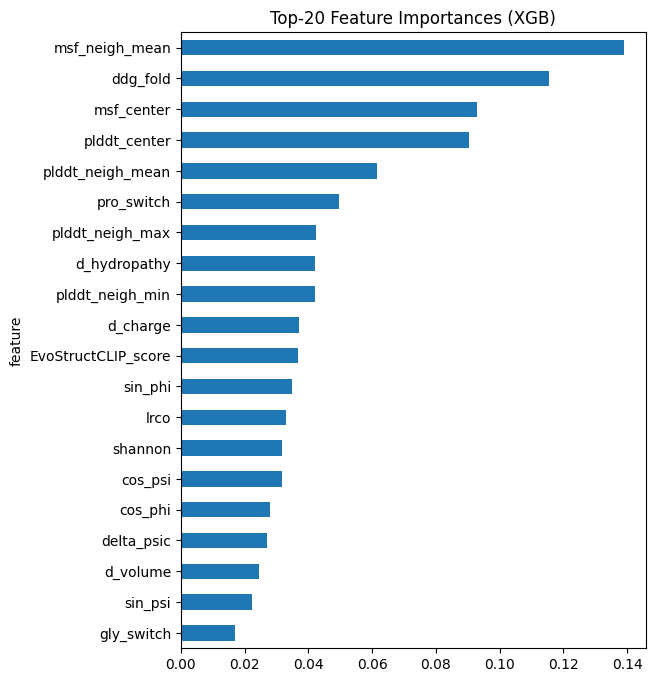

In [16]:
import matplotlib.pyplot as plt

topk = 20
imp_df.head(topk).plot(
    x="feature", y="importance", kind="barh",
    figsize=(6,8), legend=False
)
plt.gca().invert_yaxis()
plt.title("Top-20 Feature Importances (XGB)")
plt.show()


In [7]:
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Pearson r 스코어러 (maximize)
pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

base = GradientBoostingRegressor(
    # 내부 조기종료를 같이 쓰고 싶으면 유지 (손실 기준)
    n_iter_no_change=50,
    validation_fraction=0.1,
    subsample=0.9,
    random_state=42
)

param_distributions = {
    "n_estimators":   np.linspace(200, 4000, 20, dtype=int),  # 크고 천천히
    "learning_rate":  np.logspace(-4, -1, 20),                # 1e-4 ~ 0.1
    "max_depth":      [2, 3, 4],
    "min_samples_leaf":[1, 2, 3, 5, 8, 10],
    "max_features":   [0.5, 0.7, 0.9, 1.0],
    "subsample":      [0.6, 0.75, 0.9, 1.0],
    "tol":            [1e-4, 1e-3]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=60,
    scoring=pearson_scorer,  # ← Pearson r 직접 최적화
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,              # CV 최고 config로 전체 데이터 재학습
    random_state=42
)
search.fit(X_tr, y_tr)

print("Best CV Pearson r:", search.best_score_)
print("Best params:", search.best_params_)

# 외부 검증세트에서 성능 확인
best_gbr = search.best_estimator_
pred_va = best_gbr.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[GBR(Opt)] Pearson r={r:.4f} (p={p:.2e})")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV Pearson r: 0.7005128959848955
Best params: {'tol': 0.0001, 'subsample': 0.9, 'n_estimators': 3800, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 4, 'learning_rate': 0.1}
[GBR(Opt)] Pearson r=0.7103 (p=5.88e-240)


In [8]:
import numpy as np
import torch
from scipy.stats import pearsonr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EvoStructCLIP(voxel_ch=48, mb_layers=6, embed_dim=128, use_concat=True, dropout_p=0.3).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250821_clip.pth"))
model.eval()

@torch.no_grad()
def collect_meta_features_with_embeds(model, loader, device):
    model.eval()
    X_list, y_list = [], []
    for batch in loader:
        voxel   = batch["voxel"].to(device)
        ref_idx = batch["ref_idx"].to(device)
        mut_idx = batch["mut_idx"].to(device)
        msa     = batch["msa"].to(device)
        S       = batch["s_tensor"].to(device)      # [B,19]
        y       = batch["label"].float().to(device) # [B]

        out = model(voxel, ref_idx, mut_idx, msa)

        # 원래 score
        score = torch.sigmoid(out["logits"]).view(-1, 1)

        # 임베딩 벡터
        voxel_feat = out["voxel_embeds"].cpu().numpy()   # [B,128]
        msa_feat   = out["msa_embeds"].cpu().numpy()     # [B,128]
        fused      = np.concatenate([voxel_feat, msa_feat], axis=1)  # [B,256]

        # S features
        S_np = S.cpu().numpy()

        # 최종 concat
        X = np.concatenate([S_np, score.cpu().numpy(), fused], axis=1)
        y = y.view(-1).cpu().numpy()

        X_list.append(X); y_list.append(y)

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    return X_all, y_all

# 수집
X_tr, y_tr = collect_meta_features_with_embeds(model, train_loader, device)
X_va, y_va = collect_meta_features_with_embeds(model, val_loader, device)
print("train X:", X_tr.shape, "val X:", X_va.shape)  

train X: (6240, 278) val X: (1561, 278)


In [9]:
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Pearson r 스코어러 (maximize)
pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

base = GradientBoostingRegressor(
    # 내부 조기종료를 같이 쓰고 싶으면 유지 (손실 기준)
    n_iter_no_change=50,
    validation_fraction=0.1,
    subsample=0.9,
    random_state=42
)

param_distributions = {
    "n_estimators":   np.linspace(200, 4000, 20, dtype=int),  # 크고 천천히
    "learning_rate":  np.logspace(-4, -1, 20),                # 1e-4 ~ 0.1
    "max_depth":      [2, 3, 4],
    "min_samples_leaf":[1, 2, 3, 5, 8, 10],
    "max_features":   [0.5, 0.7, 0.9, 1.0],
    "subsample":      [0.6, 0.75, 0.9, 1.0],
    "tol":            [1e-4, 1e-3]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=60,
    scoring=pearson_scorer,  # ← Pearson r 직접 최적화
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,              # CV 최고 config로 전체 데이터 재학습
    random_state=42
) 
search.fit(X_tr, y_tr)   

print("Best CV Pearson r:", search.best_score_)
print("Best params:", search.best_params_)

# 외부 검증세트에서 성능 확인
best_gbr = search.best_estimator_
pred_va = best_gbr.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[GBR(Opt)] Pearson r={r:.4f} (p={p:.2e})")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV Pearson r: 0.6745156215825622
Best params: {'tol': 0.0001, 'subsample': 0.9, 'n_estimators': 3800, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 4, 'learning_rate': 0.1}
[GBR(Opt)] Pearson r=0.6840 (p=7.36e-216)


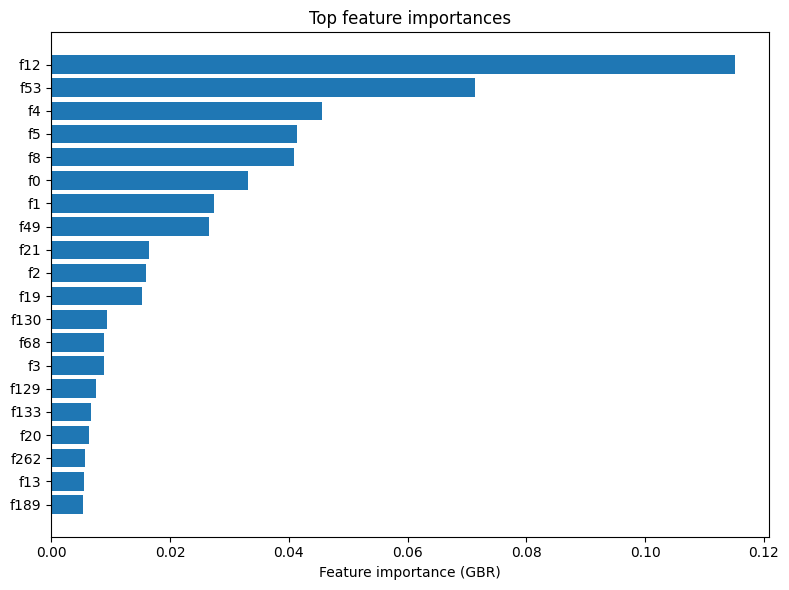

In [10]:
import matplotlib.pyplot as plt

# 1. 중요도 추출
importances = best_gbr.feature_importances_
feat_names = X_tr.columns if hasattr(X_tr, "columns") else [f"f{i}" for i in range(X_tr.shape[1])]

# 2. 중요도 정렬
idx = np.argsort(importances)[::-1]
topn = 20  # 상위 20개만 표시 (원하는 개수로 조정)

plt.figure(figsize=(8,6))
plt.barh(range(topn), importances[idx[:topn]][::-1])
plt.yticks(range(topn), [feat_names[i] for i in idx[:topn]][::-1])
plt.xlabel("Feature importance (GBR)")
plt.title("Top feature importances")
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.base import clone
import numpy as np

# 0) Pearson r 스코어러
pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

# 1) CV 단계: 조기중단 OFF
base = GradientBoostingRegressor(
    n_iter_no_change=None,   # ES 끔
    subsample=0.9,
    random_state=42
)

param_distributions = {
    "n_estimators":    np.linspace(200, 4000, 20, dtype=int),
    "learning_rate":   np.logspace(-4, -1, 20),
    "max_depth":       [2, 3, 4],
    "min_samples_leaf":[1, 2, 3, 5, 8, 10],
    "max_features":    [0.5, 0.7, 0.9, 1.0],
    "subsample":       [0.6, 0.75, 0.9, 1.0],
    "tol":             [1e-4, 1e-3]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=60,
    scoring=pearson_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42
)
search.fit(X_tr, y_tr)

print("Best CV Pearson r:", search.best_score_)
print("Best params:", search.best_params_)

# 2) 최종 단계: 큰 트리 수로 1차 학습 → staged_predict로 best_t 선택
best_params = search.best_params_.copy()

# numpy 스칼라를 파이썬 기본형으로 캐스팅 (가끔 안전)
for k, v in list(best_params.items()):
    if isinstance(v, (np.integer,)):
        best_params[k] = int(v)
    elif isinstance(v, (np.floating,)):
        best_params[k] = float(v)

# big 모델용 파라미터 구성: 딕셔너리에서만 값을 덮어씁니다
big_params = best_params.copy()
big_params["n_iter_no_change"] = None     # ES 끔 (우리가 스텝 고름)
big_params["n_estimators"] = 4000         # 충분히 크게
big_params["random_state"] = 42           # 고정

big = GradientBoostingRegressor(**big_params)
big.fit(X_tr, y_tr)

best_t, best_r = 1, -1.0
for t, yhat in enumerate(big.staged_predict(X_va), start=1):
    r, _ = pearsonr(y_va, yhat)
    if r > best_r:
        best_r, best_t = r, t

print(f"Selected n_estimators (best_t) on val: {best_t} (val Pearson r={best_r:.4f})")

# 3) 선택한 스텝으로 확정 모델 학습
final_params = best_params.copy()
final_params["n_iter_no_change"] = None
final_params["n_estimators"] = best_t
final_params["random_state"] = 42

final_model = GradientBoostingRegressor(**final_params)
final_model.fit(X_tr, y_tr)

# 4) 홀드아웃 성능
pred_va = final_model.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[GBR(final @ {best_t})] Pearson r={r:.4f} (p={p:.2e})")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV Pearson r: 0.6936020138712315
Best params: {'tol': 0.001, 'subsample': 0.75, 'n_estimators': 3800, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 4, 'learning_rate': 0.007847599703514606}
Selected n_estimators (best_t) on val: 3859 (val Pearson r=0.6987)
[GBR(final @ 3859)] Pearson r=0.6987 (p=5.21e-229)


In [12]:
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.ensemble import ExtraTreesRegressor
import numpy as np

# Pearson r 스코어러 (maximize)
pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

base = ExtraTreesRegressor(
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "n_estimators":     np.linspace(300, 3000, 15, dtype=int),
    "max_depth":        [None, 6, 10, 14, 18],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features":     [0.5, 0.7, 0.9, 1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=60,
    scoring=pearson_scorer,  # ← Pearson r 직접 최적화
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,              # CV 최고 config로 전체 데이터 재학습
    random_state=42
)
search.fit(X_tr, y_tr)

print("Best CV Pearson r:", search.best_score_)
print("Best params:", search.best_params_)

# 외부 검증세트에서 성능 확인
best_gbr = search.best_estimator_
pred_va = best_gbr.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[GBR(Opt)] Pearson r={r:.4f} (p={p:.2e})")


Fitting 5 folds for each of 60 candidates, totalling 300 fits


/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV Pearson r: 0.701688485503178
Best params: {'n_estimators': 2807, 'min_samples_leaf': 2, 'max_features': 0.9, 'max_depth': 18}
[GBR(Opt)] Pearson r=0.7075 (p=2.48e-237)


In [13]:
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from lightgbm import LGBMRegressor
import numpy as np

# 1) 일관된 타입(예: numpy)으로 통일
X_tr = np.asarray(X_tr)
X_va = np.asarray(X_va)

pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

base = LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1,
    n_jobs=-1,
    subsample_freq=1,
    device_type="gpu",  # GPU 빌드 있으면 사용
)

param_distributions = {
    "n_estimators":      np.linspace(1500, 6000, 10, dtype=int),
    "learning_rate":     np.logspace(-2.5, -1.3, 10),   # ≈ 0.003~0.05
    "num_leaves":        [31, 63, 127],
    "max_depth":         [-1, 6, 8, 10],
    "min_child_samples": [10, 20, 50],
    "subsample":         [0.7, 0.9, 1.0],
    "colsample_bytree":  [0.7, 1.0],
    "reg_lambda":        np.logspace(-2, 1, 6),
    "reg_alpha":         [0.0, 0.1, 0.5]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=24,                         # ↓ 줄여서 먼저 러프 서치
    scoring=pearson_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42
)

# 2) 조기중단(속도 ↑) - 엄밀한 CV가 목적이면 별도 전략 필요
search.fit(
    X_tr, y_tr,
)

print("Best CV Pearson r:", search.best_score_)
print("Best params:", search.best_params_)

best_lgbm = search.best_estimator_
pred_va = best_lgbm.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[LGBM(Opt)] Pearson r={r:.4f} (p={p:.2e})")


ModuleNotFoundError: No module named 'lightgbm'

In [ ]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer
from xgboost import XGBRegressor

# -----------------------------
# 데이터: X_tr, y_tr, X_va, y_va 준비되어 있다고 가정
#   X_*: (N, 20)  = [S(19D) | base_score(1D)]
#   y_*: (N,)
# -----------------------------

# 1) Pearson r 스코어러 (maximize=True)
pearson_scorer = make_scorer(lambda y, yhat: pearsonr(y, yhat)[0])

# 2) 베이스 설정 (조기종료는 CV 단계에선 쓰지 않음)
base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",      # GPU 쓰려면 'gpu_hist' (버전에 따라 device='cuda')
    random_state=42
)

# 3) 랜덤 탐색 공간 (소데이터-friendly)
param_distributions = {
    "n_estimators":      np.linspace(300, 5000, 20, dtype=int),
    "learning_rate":     np.logspace(-4, -1, 20),      # 1e-4 ~ 1e-1
    "max_depth":         [2, 3, 4, 5],
    "min_child_weight":  [1, 2, 3, 5, 8],
    "subsample":         [0.6, 0.75, 0.9, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "reg_lambda":        [0.1, 1.0, 3.0, 10.0],        # L2
    "reg_alpha":         [0.0, 0.1, 0.5, 1.0],         # L1
    "gamma":             [0.0, 0.1, 0.3, 1.0]          # 노드 분할 최소 이득
}

# 4) 5-fold CV + 랜덤서치 (Pearson r 최대화)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=60,
    scoring=pearson_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    random_state=42
)
search.fit(X_tr, y_tr)

print("Best CV Pearson r:", search.best_score_)
print("Best params:", search.best_params_)

# 5) 베스트 하이퍼파라미터로 "재학습(+옵션: 내부 조기종료)"
best_params = search.best_params_.copy()

# (선택) 조기종료용 내부 밸리데이션을 트레인 내부에서 분리
X_sub, X_hold, y_sub, y_hold = train_test_split(
    X_tr, y_tr, test_size=0.1, random_state=123
)

xgbr = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)

# XGBoost의 early_stopping은 'eval_set'이 필요 → 트레인 내부에서만 사용
# (CV 단계에선 pearson으로 모델 선택 완료했으므로 여기선 rmse 기준으로 과적합만 살짝 억제)
xgbr.fit(
    X_sub, y_sub,
    eval_set=[(X_hold, y_hold)],
    eval_metric="rmse",
    verbose=False,
    early_stopping_rounds=150
)

# 6) 홀드아웃 검증
pred_va = xgbr.predict(X_va)
r, p = pearsonr(y_va, pred_va)
print(f"[XGB(Opt)] Pearson r={r:.4f} (p={p:.2e})")

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/tmp/ipykernel_2705/3866385857.py:14: ConstantInputWarning: An input array i

Best CV Pearson r: 0.5247070908546447
Best params: {'subsample': 0.75, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'n_estimators': np.int64(4257), 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': np.float64(0.01623776739188721), 'gamma': 0.1, 'colsample_bytree': 1.0}


TypeError: XGBModel.fit() got an unexpected keyword argument 'eval_metric'